# TDT Dosimetry — Quick MIP Overview

In [1]:
# ---- CONFIG ----
DOSIMETRY_DIR = "/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/dosimetry_run_CT_0/dosimetry/opengate_simulation"  # <-- CHANGE ME

In [2]:
import json, os
from pathlib import Path
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

try:
    from json_minify import json_minify
except ImportError:
    json_minify = None

work_dir = Path(DOSIMETRY_DIR) / "work_dir"
meta_path = next(work_dir.glob("*_metadata.json"))
raw = meta_path.read_text()
meta = json.loads(json_minify(raw) if json_minify else raw)
paths = meta["paths"]
print(f"ROIs: {meta['simulated_roi_names']}")
print(f"Histories: {meta['gate']['actual_total_histories']:,.0f}")

ROIs: ['body', 'liver', 'kidney', 'spleen', 'synthetic_lesion']
Histories: 100,000,000


In [3]:
def plot_mips(arr, title, cmap="hot"):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    labels = ["Coronal", "Sagittal", "Axial"]
    for ax, proj, lbl in zip(axes, [arr.max(1), arr.max(2), arr.max(0)], labels):
        im = ax.imshow(proj, cmap=cmap, aspect="auto")
        ax.set_title(lbl, fontsize=9)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

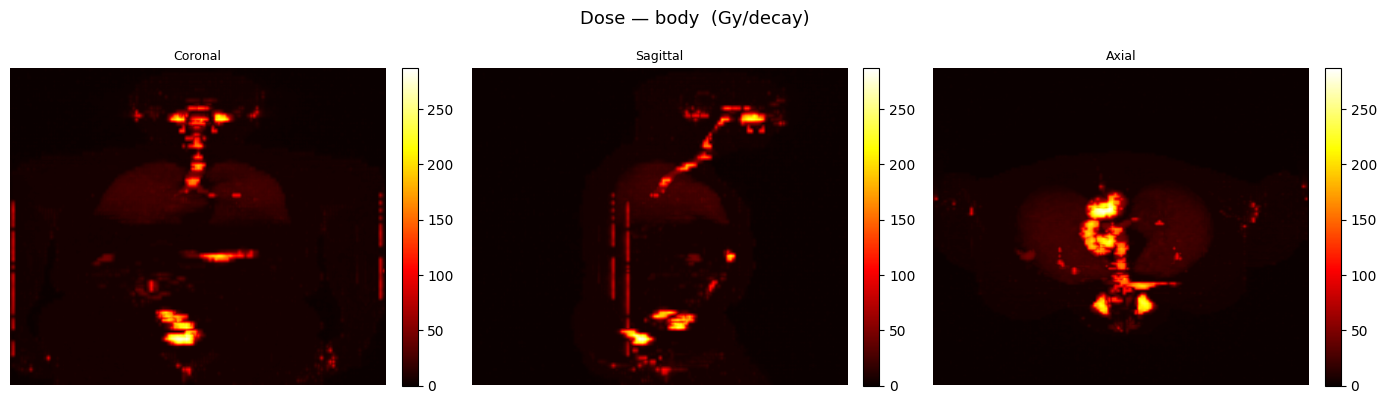

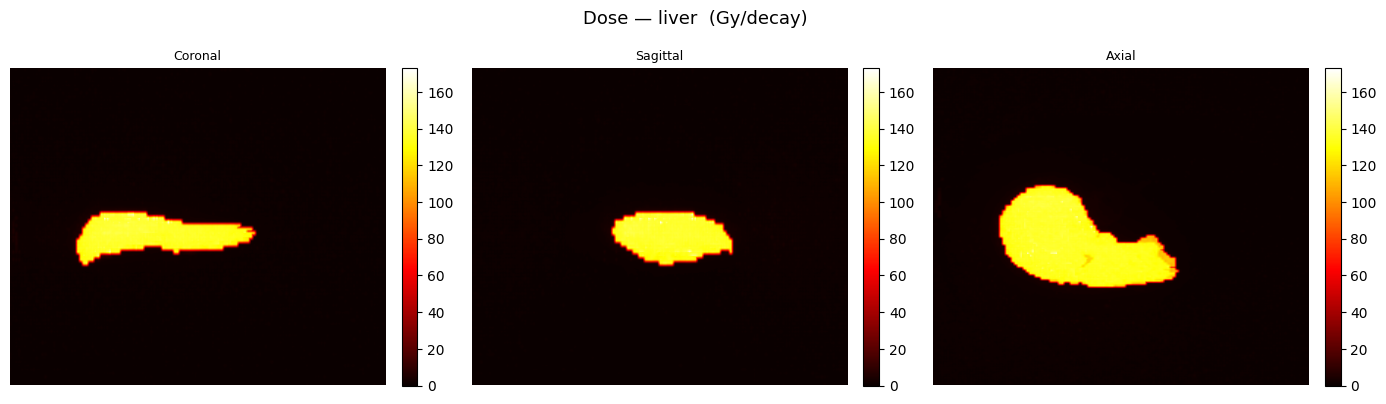

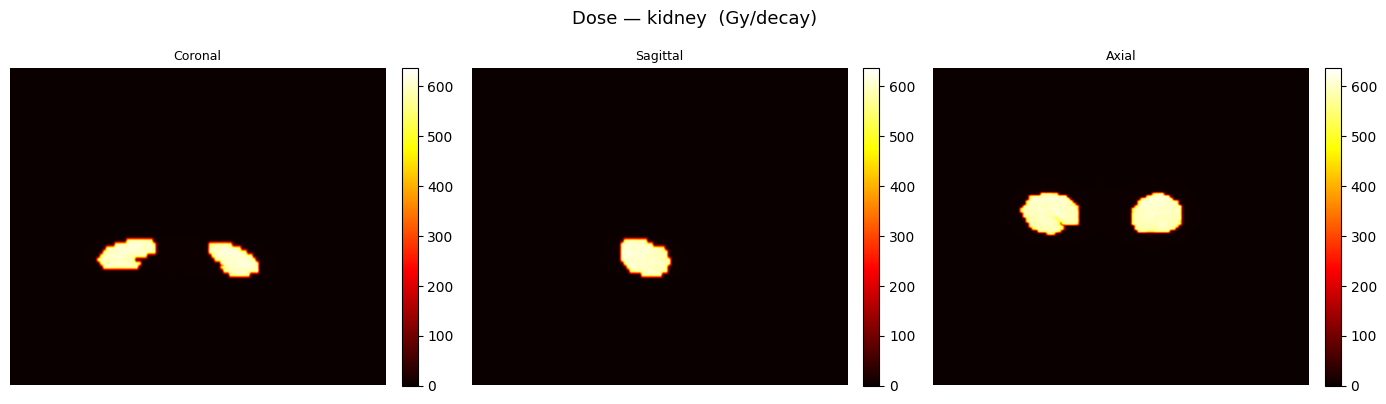

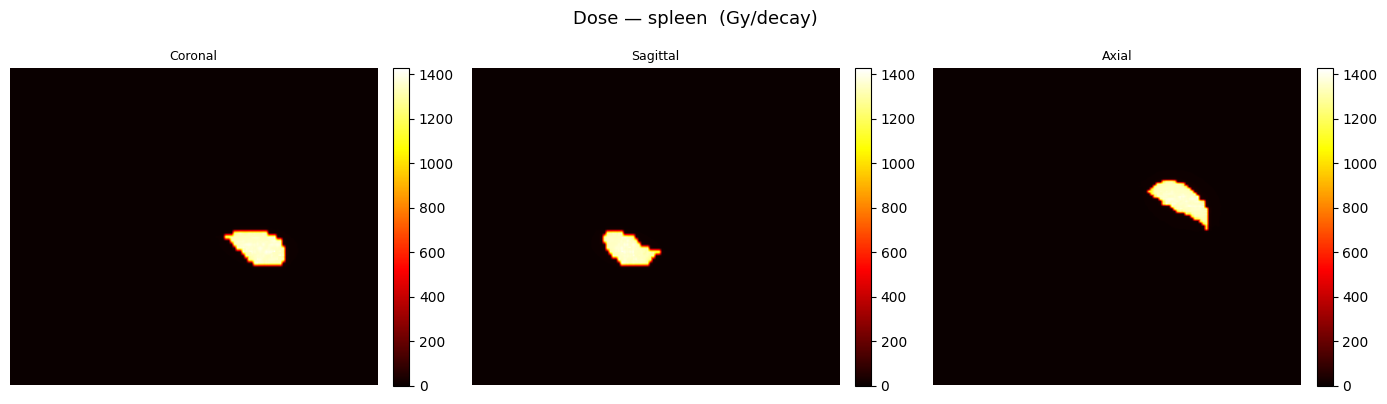

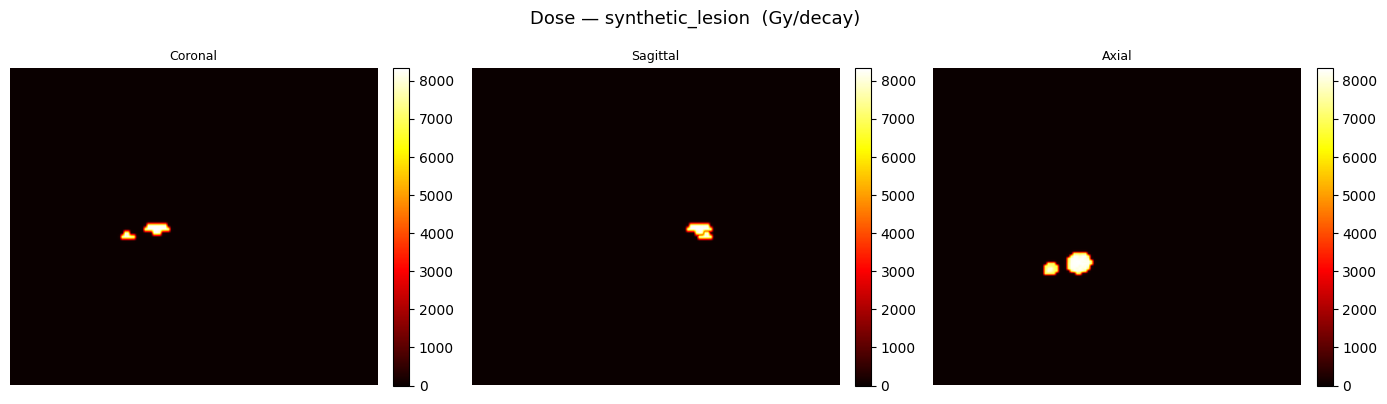

In [7]:
# Per-ROI dose MIPs
for roi, dp in paths["doses"].items():
    if os.path.isfile(dp):
        arr = sitk.GetArrayFromImage(sitk.ReadImage(dp)).astype(np.float32)
        plot_mips(arr[::-1], f"Dose — {roi}  (Gy/decay)")

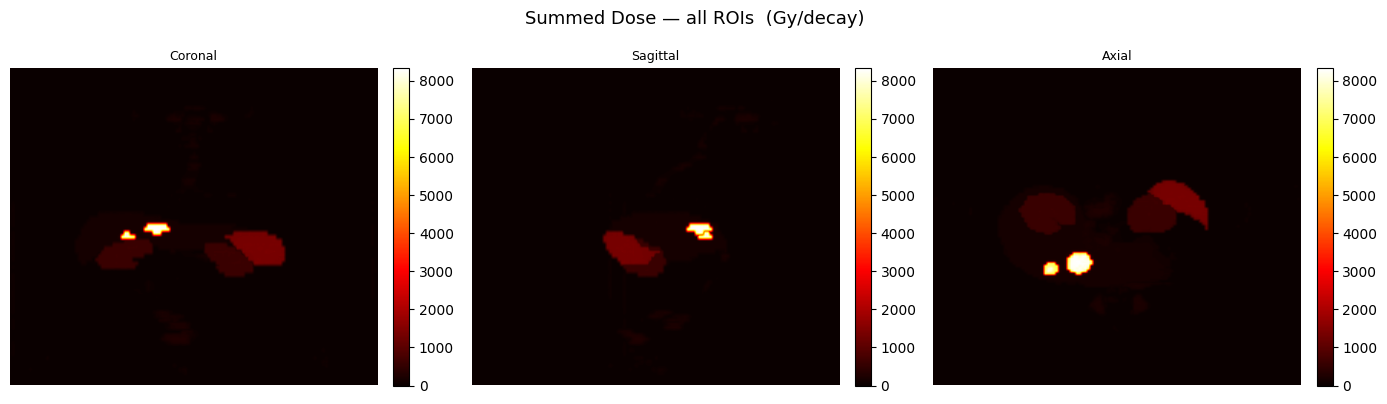

In [8]:
# Summed dose MIPs
if paths.get("sum_dose") and os.path.isfile(paths["sum_dose"]):
    arr = sitk.GetArrayFromImage(sitk.ReadImage(paths["sum_dose"])).astype(np.float32)
    plot_mips(arr[::-1], "Summed Dose — all ROIs  (Gy/decay)")

/tmp/ipykernel_232289/3423459085.py:16: RuntimeWarning: Mean of empty slice
  proj = np.nanmean(masked, axis=axis)


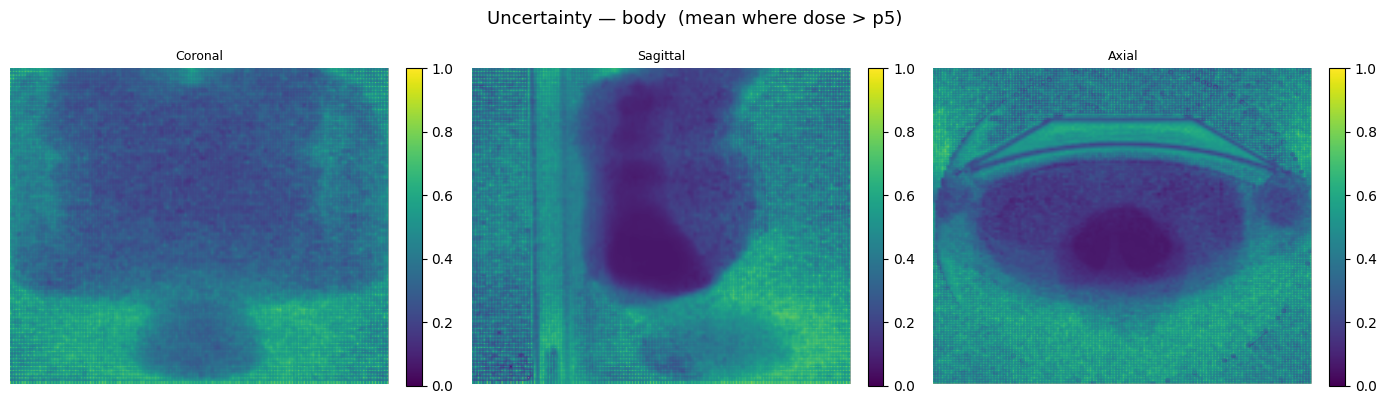

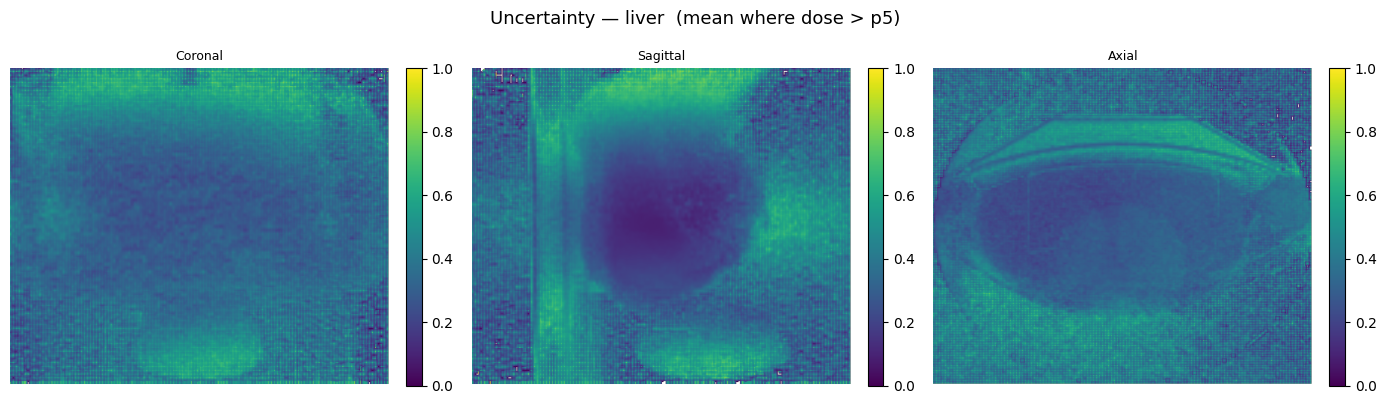

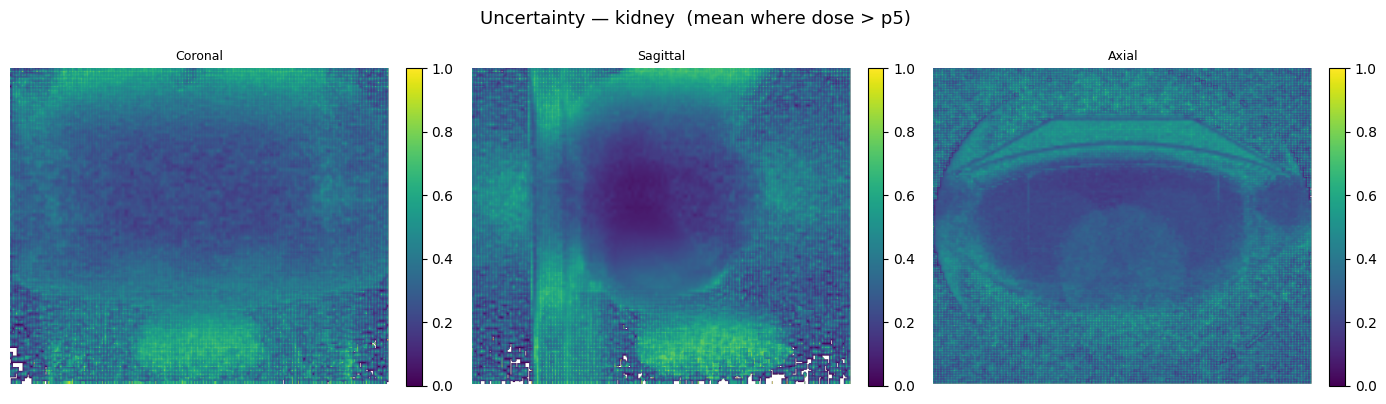

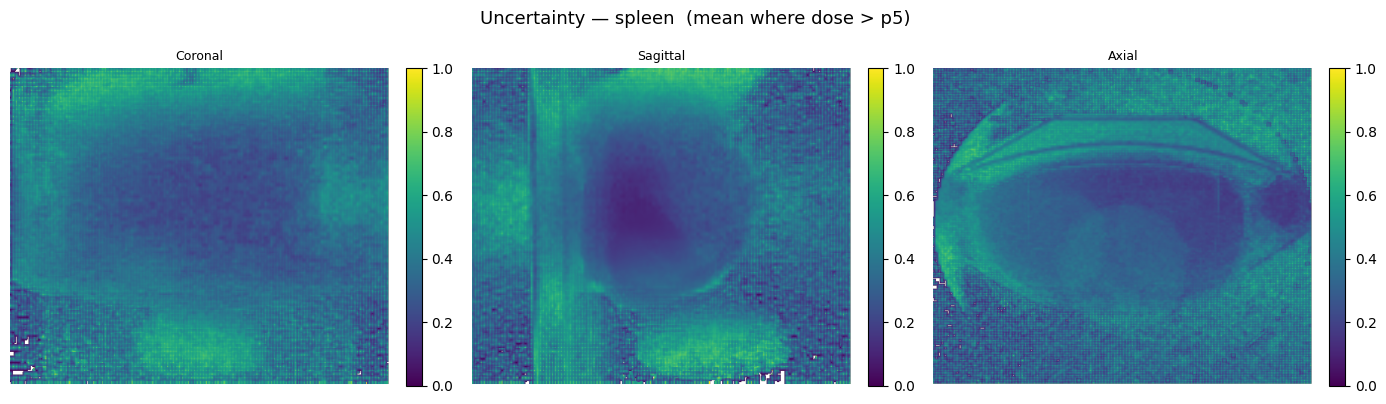

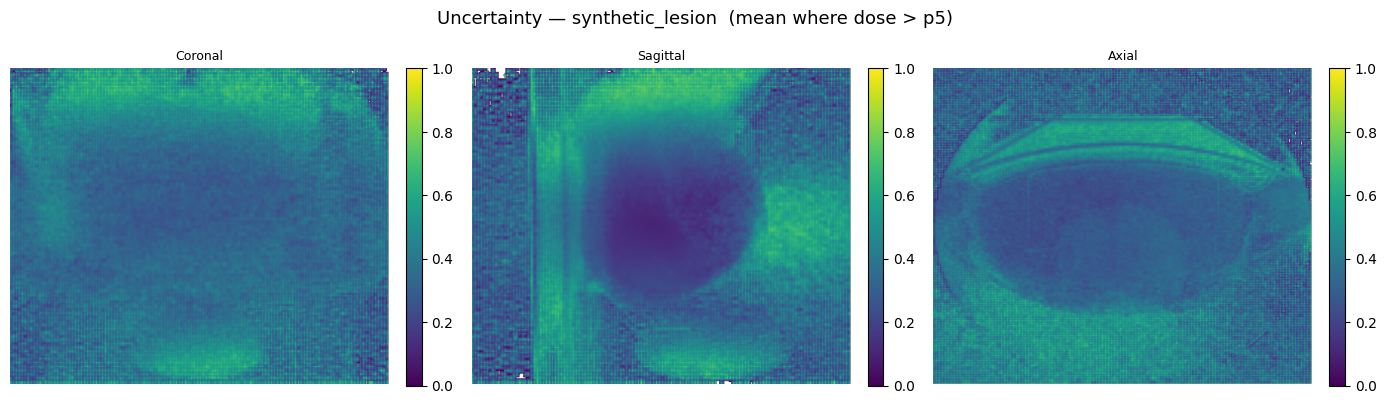

In [9]:
# Per-ROI uncertainty MIPs (weighted by dose so background doesn't dominate)
for roi, up in paths.get("uncertainties", {}).items():
    dp = paths["doses"].get(roi, "")
    if not (up and os.path.isfile(up) and dp and os.path.isfile(dp)):
        continue
    unc = sitk.GetArrayFromImage(sitk.ReadImage(up)).astype(np.float32)
    dose = sitk.GetArrayFromImage(sitk.ReadImage(dp)).astype(np.float32)

    # Mask uncertainty to voxels with meaningful dose
    threshold = np.percentile(dose[dose > 0], 5) if (dose > 0).any() else 0
    masked = np.where(dose > threshold, unc, np.nan)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    labels = ["Coronal", "Sagittal", "Axial"]
    for ax, axis, lbl in zip(axes, [1, 2, 0], labels):
        proj = np.nanmean(masked, axis=axis)
        im = ax.imshow(proj, cmap="viridis", vmin=0, vmax=1, aspect="auto")
        ax.set_title(lbl, fontsize=9)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"Uncertainty — {roi}  (mean where dose > p5)", fontsize=13)
    plt.tight_layout()
    plt.show()